# Immunization & SIR simulations on artificial networks


### Simulation workflow

Generally, the simulations work as follows:
- *Network generation*: 
    - generate $n_{nw\_reps}$ network instances for each modularity setting (corresponding to different numbers of rewiring steps) using the method described by Salathé-Jones (2010). On each instance, run the immunization and SIR simulation steps.
- *Immunization*:
    - set desired immunization coverage(s), and run each of the implemented algorithms (Random, degree-based, ACQ, CBF, BHD, BNI-LI) on the given network instance, for each obtaining a set of immunized nodes corresponding to the desired coverage
- *SIR simulation*
    - specify settings of transmission rate $\beta$, recovery rate $\gamma$ to explore
    - perform SIR simulations with the EoN module, setting sets of immunized nodes obtained from the algorithms in the previous step as initial recovered nodes (before the first infections)
    - per combination of $\beta$, $\gamma$, set of immunized nodes obtained from a single combination of algorithm and coverage setting, perform $n_{sir\_reps}$ repetitions of the SIR simulation.


In [1]:
# library imports
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import immunization_funcs as imf # this is where the immunization strategies are implemented, see immunization_funcs.py
import sim_funcs as sf # this contains the simulation sweeps
import analysis_funcs as af # this contains the analysis functions

### Example: Running simulations

In [2]:
# parameter ranges
rewire_step_list = np.arange(-1500, 1501, 1000) # rewire steps controlling modularity
coverage_list = np.array([0.1, 0.2]) # immunization coverages
beta_list = np.array([0.08]) # transmission rate
gamma_list = np.array([0.2]) # recovery rate
n_network_reps = 1 # network instances per rewire step setting
n_immunize_reps = 10 # immunization algorithm repetition
n_sir_reps = 10 # SIR simulation repetitions

# running the full parameter sweep of simulations
sf.run_gen_sweep(rewire_step_list,  
                 coverage_list, 
                 beta_list, 
                 gamma_list,
                 n_network_reps=n_network_reps,
                 n_sir_reps=n_sir_reps,
                 n_immunize_reps=n_immunize_reps,
                 output_path='results/sweep.parquet', 
                 resume=False)

rewire_steps:   0%|          | 0/4 [00:00<?, ?it/s]

coverage:   0%|          | 0/2 [00:00<?, ?it/s]

imm_rep:   0%|          | 0/10 [00:00<?, ?it/s]

d:\Studium\PoLDaE\community_immunization\immunization_funcs.py:169: UserWarning: Maximum number of expected immunization candidates 100.0 is below desired coverage 200! Automatically setting rw_reps to coverage. Any missing slots will be filled randomly.
  warnings.warn(f"Maximum number of expected immunization candidates {rw_reps * G.number_of_nodes()} is below desired coverage {int(coverage * G.number_of_nodes())}! Automatically setting rw_reps to coverage. Any missing slots will be filled randomly.")


imm_rep:   0%|          | 0/10 [00:00<?, ?it/s]

...

imm_rep:   0%|          | 0/10 [00:00<?, ?it/s]

coverage:   0%|          | 0/2 [00:00<?, ?it/s]

imm_rep:   0%|          | 0/10 [00:00<?, ?it/s]

imm_rep:   0%|          | 0/10 [00:00<?, ?it/s]

merge_checkpoints: merged 80 chunks → results/sweep.parquet


### Example: Analysing & plotting simulation results

Let's start by setting up some constants and functions:

In [3]:
# the result metrics we collected
METRICS = ["final_attack_ratio", "peak_prevalence"]
METRIC_LABELS = {
    "final_attack_ratio": "Final epidemic size",
    "peak_prevalence": "Peak prevalence",
}
METRIC_TITLES = ["Final Epidemic Size", "Peak Prevalence"]

# Columns that encode ids of simulation reps- we average and then drop them
DROP_COLS = ["network_rep", "sir_rep", "imm_rep"]

# This well be for the columns listing the 'best' algorithms based on specific result metrics
# (used throughout compute_best_algorithms and plot_algo_heatmaps)
METRIC_MAP = {
    "alg_final":    "final_attack_ratio",
    "alg_peak":     "peak_prevalence",
}

METRIC_VAR_MAP = {
    "final_attack_ratio": "R",
    "peak_prevalence": "P",
}

GROUP_COLS = ["rewire_steps", "modularity", "algorithm", "coverage", "beta", "gamma"] 
SCENARIO_COLS = ["rewire_steps", "modularity", "coverage", "beta", "gamma"]

# Modularity levels (expressed as rewire_steps) for the coverage-sweep curves
REWIRE_LEVELS = [-1500, 1500]

# Coverage levels for the modularity-sweep curves
COVERAGE_LEVELS = [0.1, 0.2]

Loading the simulation data:

In [4]:
df = pd.read_parquet("results/sweep.parquet")

df["modularity"] = df["modularity"].round(2)   # round for aggregation
# to get # cases instead of fraction
df[["final_attack_ratio", "peak_prevalence"]] = df[["final_attack_ratio", "peak_prevalence"]]*2000 

Check which algorithm performed best for a given metric:

Heatmap grid: 2 coverage levels × 4 modularity levels


<Figure size 10x10 with 0 Axes>

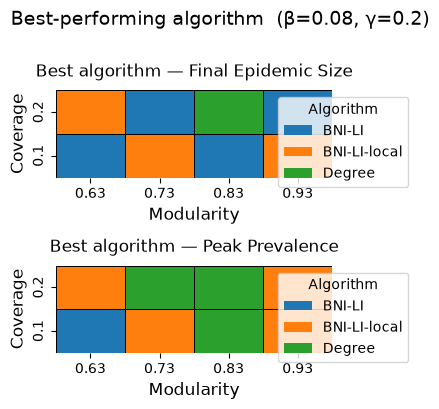

In [5]:
BETA_SLICE = 0.08
GAMMA_SLICE = 0.2
# avg over SIR / immunization / network reps, to get one mean value per metric for each parameter combo
df_avg = af.avg_over_reps(df, group_cols=GROUP_COLS, drop_cols=DROP_COLS)

# get best algorithm for each metric
best = af.compute_best_algorithms(df_avg, SCENARIO_COLS, metric_map=METRIC_MAP)

# filter y beta and gamma slice if the sim contains multiple
# When two rewire_steps values round to the same modularity, resolve ties by
# majority vote (mode) across the duplicated (coverage, modularity) cells.
alg_cols = list(METRIC_MAP.keys())
best_filtered = (
    best
    .query(f"beta == {BETA_SLICE} and gamma == {GAMMA_SLICE}")
    .groupby(["coverage", "modularity"], as_index=False)[alg_cols]
    .agg(lambda x: x.mode().iat[0])
)

print(f"Heatmap grid: {best_filtered['coverage'].nunique()} coverage levels "
      f"× {best_filtered['modularity'].nunique()} modularity levels")

# Build shared colour encoding and draw the figure
all_algorithms = sorted(
    pd.concat([best_filtered[c] for c in alg_cols]).unique()
)

algo_to_code, palette, cmap, norm, legend_handles = af.make_color_encoding(all_algorithms)
af.save_legend(legend_handles, save_path="figures/algo_legend.png")

af.plot_algo_heatmaps(
    best_filtered,
    algo_to_code=algo_to_code,
    metric_map=METRIC_MAP,
    col_titles=METRIC_TITLES,
    cmap=cmap,
    norm=norm,
    legend_handles=legend_handles,
    suptitle=f"Best-performing algorithm  (β={BETA_SLICE}, γ={GAMMA_SLICE})",
    save_path="figures/algo_heatmaps_beta0p08_gamma0p2.png",
    annotate=False
)
plt.show()

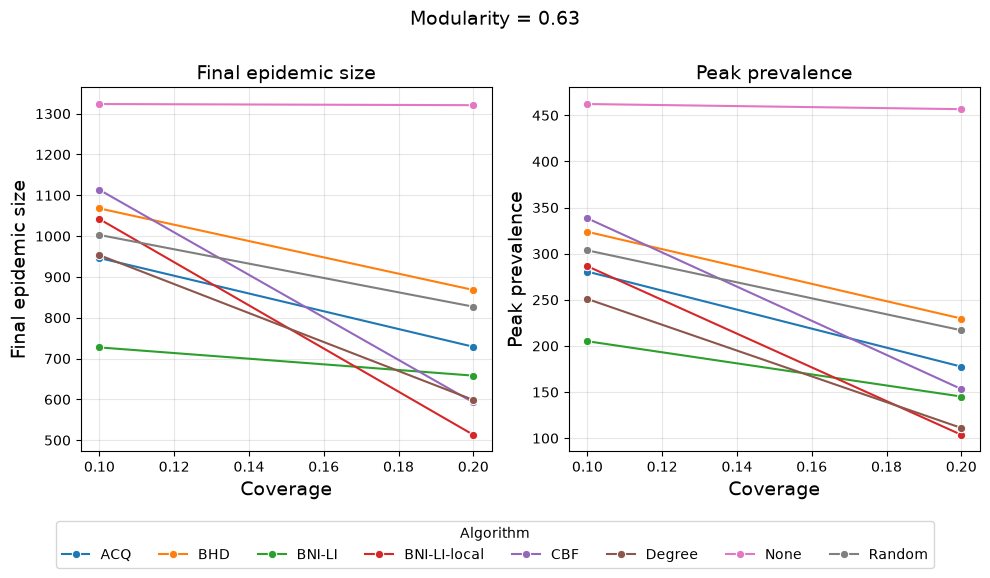

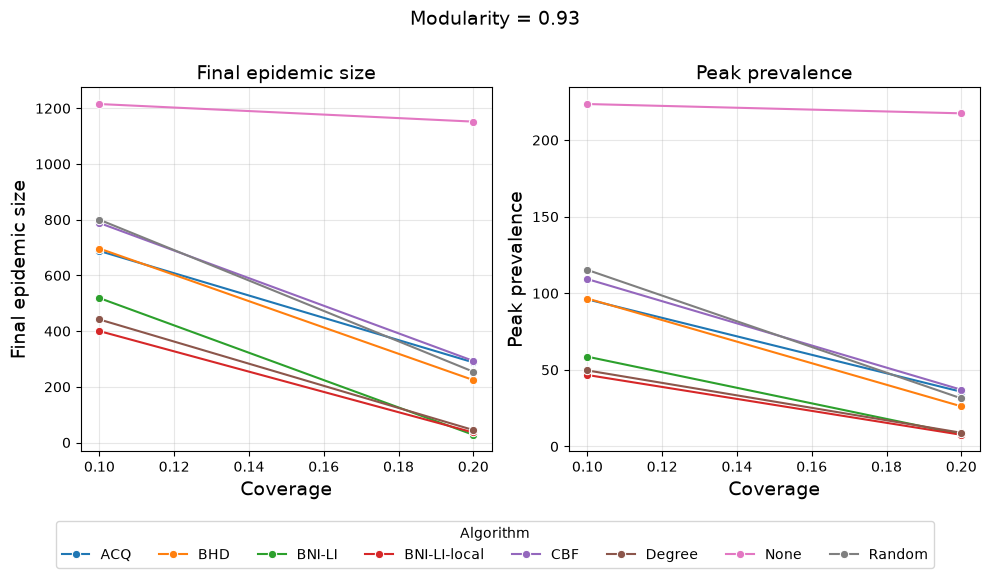

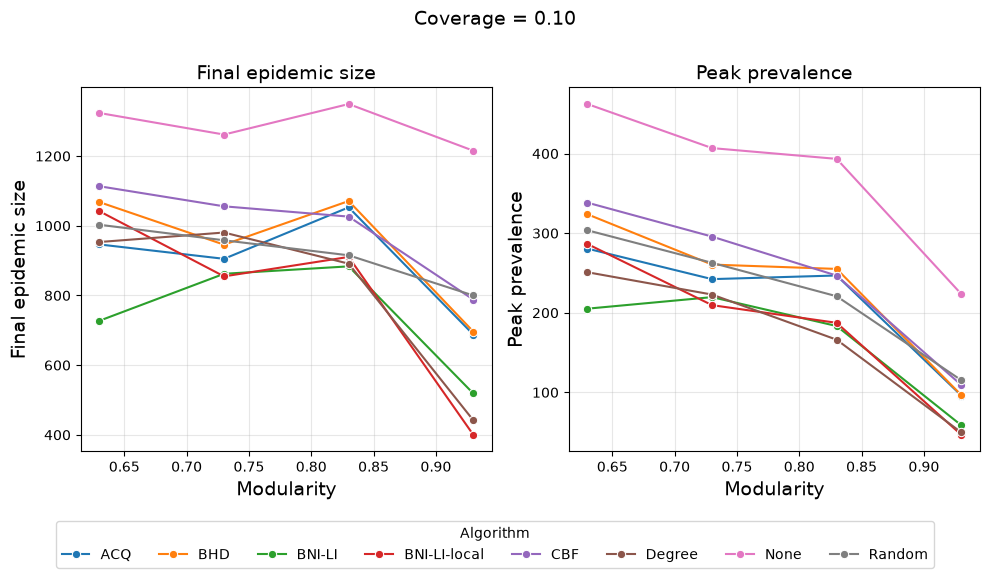

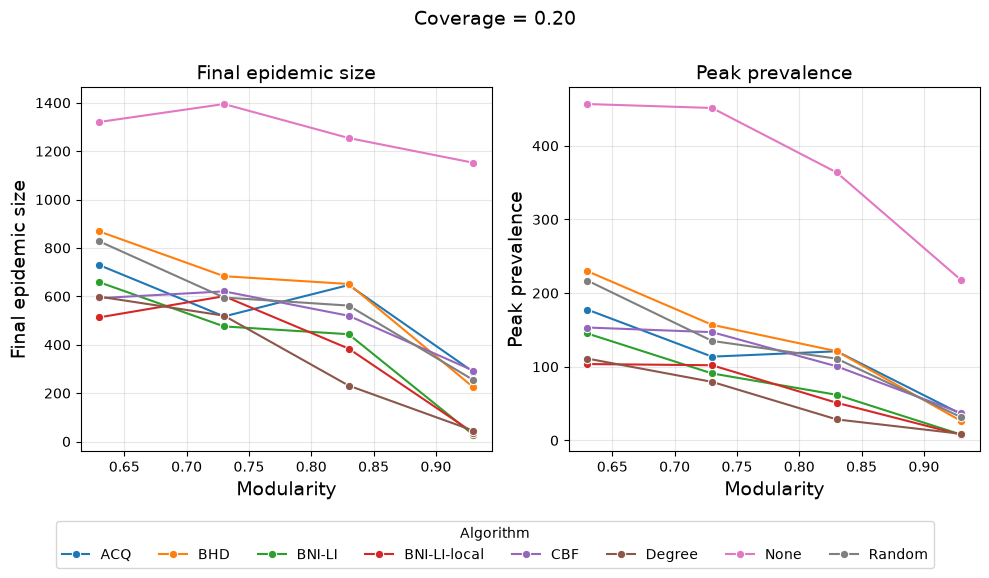

In [6]:
# filter for beta/gamma slice
df_sub = df_avg.query(f"beta == {BETA_SLICE} and gamma == {GAMMA_SLICE}")

# Build a rewire_steps → mean modularity lookup for readable slice labels.
rewire_to_mod = df_sub.groupby("rewire_steps")["modularity"].mean().round(2)

# Metric vs. coverage, for selected modularity (rewire_steps) levels 
for rw in REWIRE_LEVELS:
    subset  = df_sub.query("rewire_steps == @rw")
    mod_val = rewire_to_mod.loc[rw]
    af.plot_metrics(
        subset,
        metrics=METRICS,
        metric_labels=METRIC_LABELS,
        x_col="coverage",
        slice_col="modularity",
        slice_val=mod_val,
        x_label="Coverage",
        slice_label="Modularity",
        save_path=f"figures/metric_vs_coverage_mod{mod_val}.png",
    )

# Metric vs. modularity, for selected coverage levels 
for cov in COVERAGE_LEVELS:
    subset = df_sub.query("coverage == @cov")
    af.plot_metrics(
        subset,        
        metrics=METRICS,
        metric_labels=METRIC_LABELS,
        x_col="modularity",
        slice_col="coverage",
        slice_val=cov,
        x_label="Modularity",
        slice_label="Coverage",
        save_path=f"figures/metric_vs_modularity_cov{cov}.png",
    )

#### Pairwise comparison
Note: Red = Second algorithm is better, Blue = First algorithm is better.

Comparing algorithms: ACQ vs BNI-LI


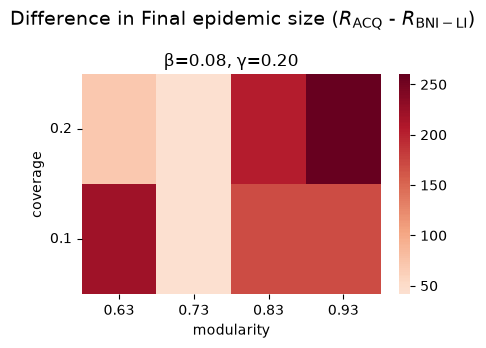

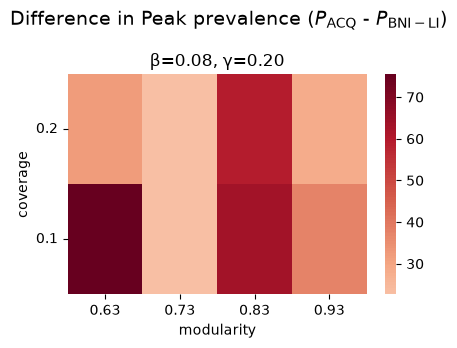

Comparing algorithms: CBF vs BNI-LI


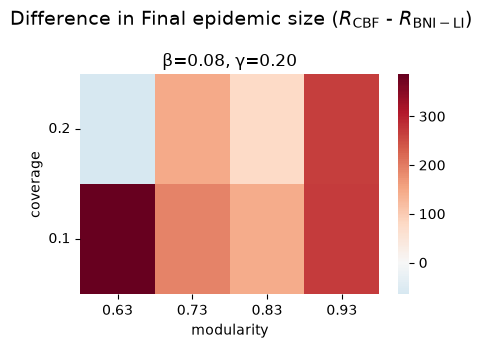

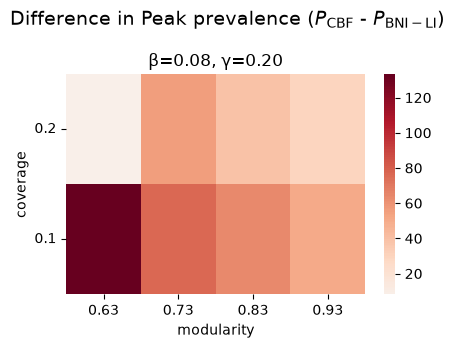

Comparing algorithms: BHD vs BNI-LI


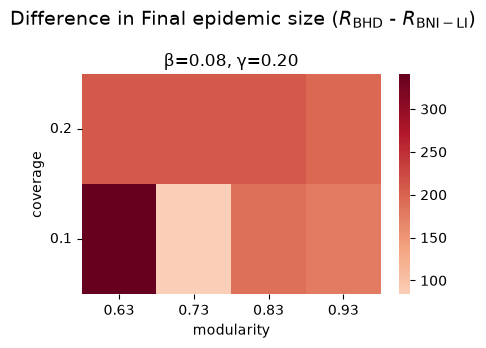

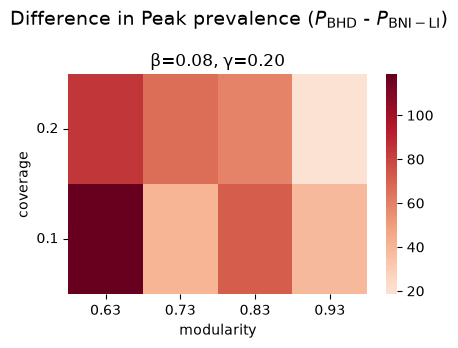

Comparing algorithms: Degree vs BNI-LI


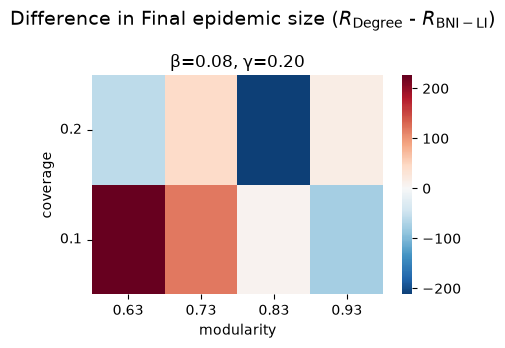

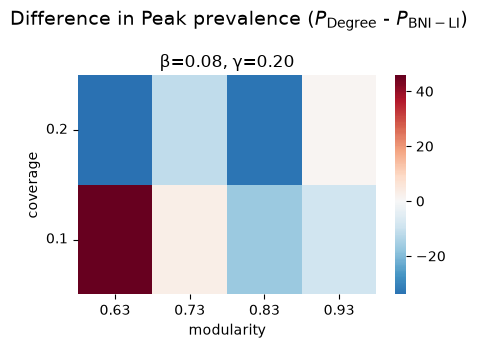

In [7]:
af.pairwise_comparison_by_metric(df_avg, 'ACQ', 'BNI-LI', METRIC_LABELS, METRIC_VAR_MAP)
af.pairwise_comparison_by_metric(df_avg, 'CBF', 'BNI-LI', METRIC_LABELS, METRIC_VAR_MAP)
af.pairwise_comparison_by_metric(df_avg, 'BHD', 'BNI-LI', METRIC_LABELS, METRIC_VAR_MAP)
af.pairwise_comparison_by_metric(df_avg, 'Degree', 'BNI-LI', METRIC_LABELS, METRIC_VAR_MAP)